# Lattice light shift: two community models, run side by side

The lattice light shift is the systematic right behind blackbody radiation
in a well-shielded strontium or ytterbium lattice clock's error budget. It
comes from the trapping laser: the light that confines the atom also
perturbs the clock frequency the experiment is trying to measure. Two
community models compute this perturbation, and both stay in active use.

Katori's group derived a closed-form harmonic/operational model that a lab
can fit directly against its own sideband spectroscopy. Beloy, Bothwell, and
their NIST collaborators built a Born-Oppenheimer-plus-WKB model that solves
the trap's true, non-parabolic geometry directly, at higher computational
cost. This notebook runs both models on the same inputs, validates each
against its own group's published numbers, and puts the two side by side in
one open pipeline.

- **Reproducing Ushijima et al. 2018's own operational trap depth and Aeppli
  et al. 2024's own lattice-light budget line (Section 2).** Solves the
  closed-form model's defining equation directly and lands inside both
  papers' published uncertainty bands.
- **Reproducing Bothwell et al. 2025's own published trap-depth-reduction
  table, all four operating points (Section 3).** The full
  Born-Oppenheimer-plus-WKB machinery, a finite-difference axial solve, a
  WKB turning-radius density of states, and a thermal average, reproduces
  the paper's own numbers to better than 0.1 percent.
- **Computing where the two models disagree, and why (Section 4).** The true
  trap's density of states grows faster with energy than the harmonic
  approximation's; Section 4 measures that growth directly and its
  consequence for the two models' predicted radial-state counts as radial
  temperature rises.

Both models take the same three per-species inputs, the E1-polarizability
slope, the combined M1+E2 polarizability, and the hyperpolarizability, and
fold them together with the atom's motional state. Six sections build the
full comparison:

- **Section 1.** An atom in a standing wave of light: the trap geometry both
  models start from.
- **Section 2.** The Katori-lineage harmonic/operational model, validated
  against its own published numbers.
- **Section 3.** The NIST Born-Oppenheimer-plus-WKB model, validated against
  its own published numbers.
- **Section 4.** Where the two models disagree, and the density-of-states
  origin of that disagreement.
- **Section 5.** A short finding: the two lineages use two different,
  non-interchangeable radial-thermal reduction formulas.
- **Section 6.** What an experimental team can use today.


In [1]:
%matplotlib inline
import math
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import run_lattice_light_shift as rlls

import cliffordclock.integrator.lattice_light_shift as lls
from cliffordclock.constants import SPEED_OF_LIGHT
from cliffordclock.ensemble.species import get_species

_notebook_start_s = time.time()
np.set_printoptions(precision=6, suppress=False)
sr87 = get_species("Sr87")
yb171 = get_species("Yb171")
print(f"species: Sr87, clock frequency nu_0 = {sr87.clock_frequency_hz:.6f} Hz")
print(f"species: Yb171, clock frequency nu_0 = {yb171.clock_frequency_hz:.6f} Hz")

species: Sr87, clock frequency nu_0 = 429228004229873.375000 Hz
species: Yb171, clock frequency nu_0 = 518295836590863.625000 Hz


## 1. An atom in a standing wave of light

Two laser beams travel toward each other and overlap, and their
interference builds a standing wave along one axis. The standing wave's
intensity peaks form a row of potential wells spaced by half the laser's
wavelength, an optical lattice. An atom loaded into one well sits confined
along the beam axis by the light's own intensity gradient, and confined in
the two directions across the beam by the beam's Gaussian intensity
profile.

The same trapping light also shifts the atom's clock frequency. The atom's
two clock states polarize by different amounts in the trapping light's
electric field, an E1 differential polarizability that depends on how far
the trapping laser sits from its own magic frequency, plus smaller M1+E2
and hyperpolarizability corrections. That state-dependent polarization
changes the trap depth each clock state feels, and the difference between
the two depths shows up as a shift in the measured clock frequency: the
lattice light shift both models in this notebook compute.

Along the beam axis, the well follows a squared cosine, curving like a
parabola near the bottom and flattening again near the top. The squared
cosine has a finite depth, set by the laser's intensity; a parabola keeps
curving upward without limit. A Gaussian factor set by the beam's waist
confines the atom in the two directions across the beam axis, and lowers
the local depth as the atom moves away from the beam's center.

Which part of that well an atom samples depends on two things. The first is
its axial vibrational level along the beam axis, its axial quantum number
n_z. The second is how far its radial motion carries it into the Gaussian
tail across the beam, set by its radial temperature Tr. Both models fold
this motional dependence into the light shift, each its own way.

The figure below draws the axial well twice at one representative depth,
once as the true squared cosine and once as the harmonic parabola both
models start from, with each model's first four vibrational levels marked
on its own curve.


In [2]:
DEPTH_ER_SCHEMATIC = 50.0
N_LEVELS_SCHEMATIC = 4

levels_cos2 = lls.axial_energies_er(DEPTH_ER_SCHEMATIC, N_LEVELS_SCHEMATIC, potential="cos2")
levels_harmonic = lls.axial_energies_er(
    DEPTH_ER_SCHEMATIC, N_LEVELS_SCHEMATIC, potential="harmonic"
)
diff_ground = levels_harmonic[0] - levels_cos2[0]
print("true (cos^2) axial levels, E_R:", levels_cos2)
print("harmonic axial levels, E_R:   ", levels_harmonic)

true (cos^2) axial levels, E_R: [-43.188836 -30.132999 -18.282051  -7.632666]
harmonic axial levels, E_R:    [-42.928931 -28.786741 -14.64381   -0.494511]


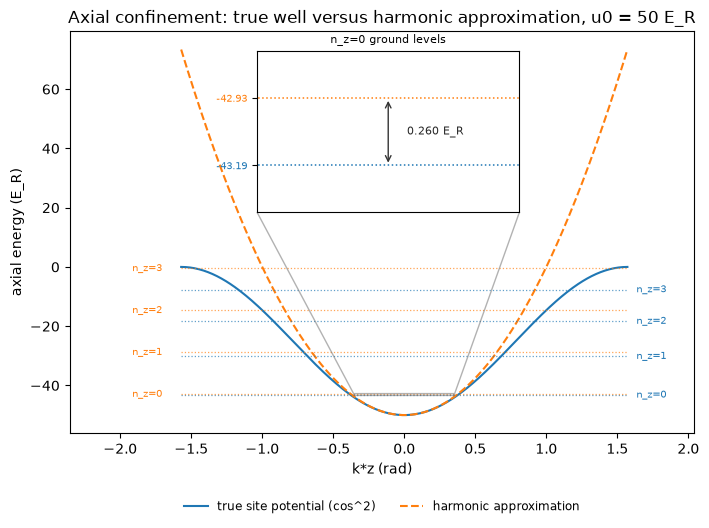

In [3]:
x_schematic = np.linspace(-math.pi / 2.0, math.pi / 2.0, 400)
v_cos2 = -DEPTH_ER_SCHEMATIC * np.cos(x_schematic) ** 2
v_harmonic = -DEPTH_ER_SCHEMATIC + DEPTH_ER_SCHEMATIC * x_schematic**2
half_width = math.pi / 2.0

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.plot(x_schematic, v_cos2, color="C0", label="true site potential (cos^2)")
ax.plot(x_schematic, v_harmonic, color="C1", linestyle="--", label="harmonic approximation")
for n, e in enumerate(levels_cos2):
    ax.hlines(e, -half_width, half_width, color="C0", linewidth=0.9, linestyle=":", alpha=0.7)
    ax.annotate(f"n_z={n}", xy=(half_width * 1.04, e), fontsize=7.5, color="C0", va="center")
for n, e in enumerate(levels_harmonic):
    ax.hlines(e, -half_width, half_width, color="C1", linewidth=0.9, linestyle=":", alpha=0.7)
    ax.annotate(f"n_z={n}", xy=(-half_width * 1.22, e), fontsize=7.5, color="C1", va="center")
ax.set_xlim(-half_width * 1.5, half_width * 1.3)
ax.set_xlabel("k*z (rad)")
ax.set_ylabel("axial energy (E_R)")
ax.set_title(
    f"Axial confinement: true well versus harmonic approximation, u0 = {DEPTH_ER_SCHEMATIC:.0f} E_R"
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=8.5, frameon=False)

# Inset: the n_z=0 ground-level gap is about 0.5 percent of the full y-range,
# invisible at full scale, so it gets its own zoomed panel with the value
# annotated directly.
inset_pad = 0.18
inset_lo = min(levels_cos2[0], levels_harmonic[0]) - inset_pad
inset_hi = max(levels_cos2[0], levels_harmonic[0]) + inset_pad
axins = ax.inset_axes([0.30, 0.55, 0.42, 0.40])
axins.plot(x_schematic, v_cos2, color="C0")
axins.plot(x_schematic, v_harmonic, color="C1", linestyle="--")
axins.hlines(levels_cos2[0], -half_width, half_width, color="C0", linewidth=1.1, linestyle=":")
axins.hlines(levels_harmonic[0], -half_width, half_width, color="C1", linewidth=1.1, linestyle=":")
axins.annotate(
    "",
    xy=(0.0, levels_cos2[0]),
    xytext=(0.0, levels_harmonic[0]),
    arrowprops={"arrowstyle": "<->", "color": "0.2", "linewidth": 1.0},
)
axins.annotate(
    f"{diff_ground:.3f} E_R",
    xy=(0.05, (levels_cos2[0] + levels_harmonic[0]) / 2.0),
    fontsize=8,
    color="0.15",
    va="center",
)
axins.set_xlim(-0.35, 0.35)
axins.set_ylim(inset_lo, inset_hi)
axins.set_xticks([])
axins.set_yticks([levels_cos2[0], levels_harmonic[0]])
axins.set_yticklabels([f"{levels_cos2[0]:.2f}", f"{levels_harmonic[0]:.2f}"], fontsize=7)
axins.get_yticklabels()[0].set_color("C0")
axins.get_yticklabels()[1].set_color("C1")
axins.set_title("n_z=0 ground levels", fontsize=8)
for spine in axins.spines.values():
    spine.set_linewidth(0.8)
ax.indicate_inset_zoom(axins, edgecolor="0.4")

fig.tight_layout()
plt.show()

In [4]:
display(
    Markdown(
        f"**True ground level (n_z=0):** {levels_cos2[0]:.3f} E_R  \n"
        f"**Harmonic ground level (n_z=0):** {levels_harmonic[0]:.3f} E_R  \n"
        f"**True well deeper by:** {diff_ground:.3f} E_R at u0 = {DEPTH_ER_SCHEMATIC:.0f} E_R"
    )
)

**True ground level (n_z=0):** -43.189 E_R  
**Harmonic ground level (n_z=0):** -42.929 E_R  
**True well deeper by:** 0.260 E_R at u0 = 50 E_R

Near the well's bottom, the squared cosine adds an attractive quartic
correction on top of the parabola, cos^2(x) ~= 1 - x^2 + x^4/3, and that
correction pulls the true ground level below the harmonic one, the
difference printed above. Near the top, the opposite pattern appears: the
true well's higher levels crowd closer together than the harmonic ladder's
evenly spaced steps, because the flattening well runs out of space before a
parabola would. Section 4 measures that crowding directly, as a density of
states.


## 2. The Katori-lineage harmonic/operational model, validated

Ushijima, Takamoto, and Katori wrote the light shift as a harmonic-oscillator
perturbative series in the reduced trap depth u, the peak trap depth
measured in recoil-energy units E_R. Three per-species coefficients set the
series: the E1-polarizability slope with respect to the trapping laser's
detuning from its magic frequency, the combined M1+E2 polarizability, and
the hyperpolarizability. A lab measures these three coefficients once, from
its own sideband spectroscopy, and the series then predicts the light shift
at any trap depth and detuning without a new fit.

One particular trap depth and detuning cancel the light shift to first
order in both u and n_z at once, the operational magic point. Working at
that point makes the clock's frequency insensitive to small drifts in trap
depth, the reason labs seek it out. Ushijima et al. give an approximate
closed form for this point; this notebook solves their defining equation
directly for the exact point that approximate form estimates.


In [5]:
target1 = rlls.run_ushijima_operational_point_case()

u_op_pred_str = f"{target1.u_op_predicted:.2f}"
u_op_pub_str = f"{target1.u_op_published:.0f}({target1.u_op_published_uncertainty:.0f})"
detuning_pred_str = f"{target1.detuning_hz_op_predicted / 1e6:.3f}"
detuning_pub_str = (
    f"{target1.detuning_hz_op_published / 1e6:.1f}"
    f"({target1.detuning_hz_op_published_uncertainty / 1e6:.1f})"
)

target1_table_md = "\n".join(
    [
        "| quantity | this engine | published | within published uncertainty |",
        "|---|---|---|---|",
        f"| u_op (E_R) | {u_op_pred_str} | {u_op_pub_str} | "
        f"{target1.u_op_within_published_uncertainty} |",
        f"| detuning_L_op (MHz) | {detuning_pred_str} | {detuning_pub_str} | "
        f"{target1.detuning_op_within_published_uncertainty} |",
    ]
)
display(Markdown(target1_table_md))
print(f"case_class: {target1.case_class}")
print(f"source: {target1.citation}")

| quantity | this engine | published | within published uncertainty |
|---|---|---|---|
| u_op (E_R) | 71.72 | 72(2) | True |
| detuning_L_op (MHz) | 5.286 | 5.3(0.2) | True |

case_class: arithmetic_reproduction
source: Ushijima, Takamoto, Katori, PRL 121, 263202 (2018), main text and Eqs. 14-15


Both quantities land inside Ushijima et al.'s published uncertainty, the
table's rightmost column. This validates the closed-form model's own
defining equation and its Table I coefficients end to end, using a direct
numerical solve of Eq. 1.

A lattice clock's total systematic budget lists each identified frequency
shift as its own line item, with a predicted size and an uncertainty.
Aeppli et al. 2024 publish one such line item for the lattice light shift,
at their own operating trap depth, detuning, and radial temperature,
reusing the same coefficients Kim et al. 2023 measured. The next table
recomputes that budget line from Kim et al.'s own published coefficients
and the JILA lineage's own radial-thermal reduction factor, covered in
Section 5.


In [6]:
target2 = rlls.run_aeppli_lattice_line_item_case()

target2_table_md = "\n".join(
    [
        "| quantity | value |",
        "|---|---|",
        f"| u0 (E_R) | {target2.u0:.2f} |",
        f"| detuning (MHz) | {target2.detuning_hz / 1e6:.1f} |",
        f"| Tr (nK) | {target2.radial_temperature_k * 1e9:.0f} |",
        f"| this engine, shift (1e-19) | {target2.predicted_shift_fractional * 1e19:+.3f} "
        f"+/- {target2.predicted_uncertainty_fractional * 1e19:.3f} |",
        f"| published, shift (1e-19) | {target2.published_shift_fractional * 1e19:+.3f} "
        f"+/- {target2.published_uncertainty_fractional * 1e19:.3f} |",
        f"| bands overlap | {target2.bands_overlap} |",
        f"| kpi_verdict | **{target2.kpi_verdict}** |",
    ]
)
display(Markdown(target2_table_md))
print(f"case_class: {target2.case_class}")
print(f"source: {target2.citation}")

| quantity | value |
|---|---|
| u0 (E_R) | 15.06 |
| detuning (MHz) | 10.5 |
| Tr (nK) | 120 |
| this engine, shift (1e-19) | -0.056 +/- 2.218 |
| published, shift (1e-19) | -0.100 +/- 3.200 |
| bands overlap | True |
| kpi_verdict | **MET** |

case_class: arithmetic_reproduction
source: Aeppli, Kim, Warfield, Safronova, Ye, PRL 133, 023401 (2024), Table I; coefficients and Tr from Kim, Aeppli, Bothwell, Ye, PRL 130, 113203 (2023)


The two uncertainty bands overlap, and kpi_verdict reads MET. Section 3
turns to the second community model, which solves the trap's true geometry
directly, without approximating it as a harmonic well.


## 3. The NIST Born-Oppenheimer-plus-WKB model, validated

Beloy, McGrew, and their NIST collaborators solve the trap's true confining
potential directly: a Born-Oppenheimer separation along the beam axis,
solved by numerical diagonalization, followed by a WKB treatment of the
atom's motion across the beam.

That axial solve gives each vibrational band's energy as a function of
radius, U_nz(rho). The WKB step turns that radial energy curve into a
density of states, the number of radial levels per unit energy, and a
thermal average over the atom's radial temperature Tr folds that density of
states into three per-band factors: X, Y, and Z.

X weights the E1-polarizability term by the axial band's own cos^2(kz)
expectation value, radially averaged over the atom's thermal population. Y
does the same for the combined M1+E2 term, weighted by sin^2(kz). Z weighs
the hyperpolarizability term by cos^4(kz), radially averaged the same way.
In the deep, cold limit, an atom sitting at the site center, X and Z both
approach 1 and Y approaches 0; a warmer or shallower trap pulls all three
away from that limit.

This validation checks that machinery, finite-difference axial solve, WKB
density of states, and thermal average end to end, against Bothwell et al.
2025's own published X, Y, Z table, all four of their operating points.


In [7]:
target3a = rlls.run_bothwell_table1_reproduction_case()

rows_md = "\n".join(
    f"| {r['u0']:.1f} | {r['tr_nk']:.0f} | {r['x_predicted']:.4f} | {r['x_published_bowkb']:.4f} | "
    f"{r['y_predicted']:.4f} | {r['y_published_bowkb']:.4f} | {r['z_predicted']:.4f} | "
    f"{r['z_published_bowkb']:.4f} | {r['max_abs_relative_error']:.2e} |"
    for r in target3a.rows
)
target3a_table_md = "\n".join(
    [
        "| u0 (E_R) | Tr (nK) | X, this engine | X, published | Y, this engine | Y, published | "
        "Z, this engine | Z, published | worst relative error |",
        "|---|---|---|---|---|---|---|---|---|",
        rows_md,
    ]
)
display(Markdown(target3a_table_md))
print(
    f"worst relative error across all 4 rows: {target3a.worst_relative_error:.2e} "
    f"(tolerance {target3a.tolerance_relative:.0%})"
)
print(f"kpi_verdict: {target3a.kpi_verdict}")
print(f"case_class: {target3a.case_class}")
print(f"source: {target3a.citation}")

| u0 (E_R) | Tr (nK) | X, this engine | X, published | Y, this engine | Y, published | Z, this engine | Z, published | worst relative error |
|---|---|---|---|---|---|---|---|---|
| 56.8 | 650 | 0.7855 | 0.7850 | 0.0608 | 0.0608 | 0.6455 | 0.6450 | 7.18e-04 |
| 66.4 | 550 | 0.8378 | 0.8380 | 0.0580 | 0.0580 | 0.7187 | 0.7190 | 4.59e-04 |
| 86.2 | 600 | 0.8643 | 0.8640 | 0.0515 | 0.0515 | 0.7588 | 0.7590 | 4.24e-04 |
| 112.2 | 720 | 0.8786 | 0.8790 | 0.0454 | 0.0454 | 0.7813 | 0.7810 | 8.84e-04 |

worst relative error across all 4 rows: 8.84e-04 (tolerance 1%)
kpi_verdict: MET
case_class: arithmetic_reproduction
source: Bothwell, Hunt, Siegel, Hassan, Grogan, Kobayashi, Gibble, Porsev, Safronova, Brown, Beloy, Ludlow, PRL 134, 033201 (2025), Appendix A Table I


Every one of the twelve published values above, four rows times three
factors, falls inside the stated one percent tolerance, the worst case
landing about ten times inside it. This is the strongest single validation
available for the Born-Oppenheimer-plus-WKB machinery in this project: a
published cross-check table, reproduced end to end from a real
finite-difference solve and a real WKB density of states, with zero fitted
parameters. Section 4 uses this same machinery to show where and why the
two models start to disagree.


## 4. Where the two models disagree, and why

A harmonic well's radial confinement stays parabolic at every energy, so
its density of states, the number of radial levels available per unit of
extra energy, grows in a fixed, simple way as energy rises. The true site
potential's radial confinement comes from a Gaussian factor, and its axial
confinement follows a squared cosine; both flatten well before the atom
reaches the trap's edge. That flattening makes the true density of states
grow faster than the harmonic one as energy rises toward the edge.

The figure below plots both density-of-states functions, Beloy et al.'s
closed harmonic form and the true numerical form, across the ground axial
band's energy range at one representative trap depth.


In [8]:
DOS_U0_ER = 100.0
DOS_N_POINTS = 40

wavelength_bothwell_m = SPEED_OF_LIGHT / rlls.BOTHWELL_2025_MAGIC_FREQUENCY_HZ
dos_site = lls.make_site_potential(
    depth_er=DOS_U0_ER, waist_m=50e-6, wavelength_m=wavelength_bothwell_m, mass_kg=yb171.mass_kg
)
e_r_dos = dos_site.recoil_energy_j_value
e0_cos2_j = lls.axial_band_energy_er(dos_site, 0, 0.0, potential="cos2") * e_r_dos
e0_harmonic_j = lls.axial_band_energy_er(dos_site, 0, 0.0, potential="harmonic") * e_r_dos

energies_cos2_j = np.linspace(e0_cos2_j, -1e-3 * e_r_dos, DOS_N_POINTS)
energies_harmonic_j = np.linspace(e0_harmonic_j, -1e-3 * e_r_dos, DOS_N_POINTS)

g_cos2 = np.array(
    [
        lls.bo_wkb_density_of_states(dos_site, 0, e, potential="cos2") * e_r_dos
        for e in energies_cos2_j
    ]
)
g_harmonic = np.array(
    [
        lls.harmonic_density_of_states_closed_form(dos_site, 0, e) * e_r_dos
        for e in energies_harmonic_j
    ]
)
ratio_near_edge = g_cos2[-1] / g_harmonic[-1]
print(f"density-of-states ratio (true/harmonic) near the band edge: {ratio_near_edge:.2f}")

density-of-states ratio (true/harmonic) near the band edge: 4.81


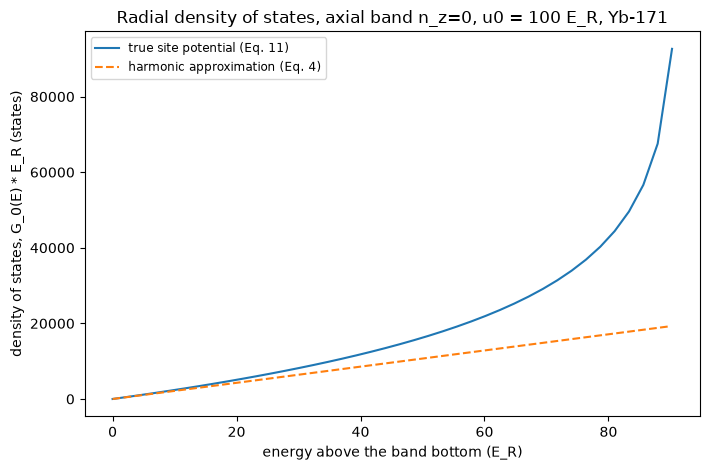

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
ax.plot(
    (energies_cos2_j - e0_cos2_j) / e_r_dos,
    g_cos2,
    color="C0",
    label="true site potential (Eq. 11)",
)
ax.plot(
    (energies_harmonic_j - e0_harmonic_j) / e_r_dos,
    g_harmonic,
    color="C1",
    linestyle="--",
    label="harmonic approximation (Eq. 4)",
)
ax.set_xlabel("energy above the band bottom (E_R)")
ax.set_ylabel("density of states, G_0(E) * E_R (states)")
ax.set_title(f"Radial density of states, axial band n_z=0, u0 = {DOS_U0_ER:.0f} E_R, Yb-171")
ax.legend(fontsize=8.5)
fig.tight_layout()
plt.show()

Beloy et al.'s closed harmonic form (Eq. 4) is a straight line in energy,
visible directly in the figure. The true numerical density of states
(Eq. 11) starts at the same value near the band bottom and curves above the
harmonic line as energy rises. It grows faster because the true well's
flattening geometry opens up more radial room per unit of extra energy than
a parabola does, reaching the ratio printed above by the top of the band.

That growing gap has a direct consequence for how many radial levels a warm
atom's motion explores. The table below turns the gap into a number: the
cumulative count of radial states available to a thermal population, both
models, as a function of radial temperature.


In [10]:
dos_contrast = rlls.run_density_of_states_contrast_case()

dos_rows_md = "\n".join(
    f"| {r['radial_temperature_k'] * 1e9:.0f} | {r['cumulative_states_cos2']:.3e} | "
    f"{r['cumulative_states_harmonic']:.3e} | {r['ratio_cos2_over_harmonic']:.3f} |"
    for r in dos_contrast.rows
)
dos_table_md = "\n".join(
    [
        "| Tr (nK) | radial states, true potential | radial states, harmonic | ratio |",
        "|---|---|---|---|",
        dos_rows_md,
    ]
)
display(Markdown(dos_table_md))
print(
    f"cumulative radial states from the axial band-0 bottom up to one thermal quantum "
    f"above it, both models, Yb-171, u0 = {dos_contrast.u0:.0f} E_R"
)

| Tr (nK) | radial states, true potential | radial states, harmonic | ratio |
|---|---|---|---|
| 50 | 2.989e+01 | 2.834e+01 | 1.055 |
| 100 | 1.198e+02 | 1.134e+02 | 1.057 |
| 200 | 4.809e+02 | 4.534e+02 | 1.061 |
| 400 | 1.938e+03 | 1.814e+03 | 1.069 |
| 800 | 7.874e+03 | 7.255e+03 | 1.085 |
| 1600 | 3.254e+04 | 2.902e+04 | 1.121 |

cumulative radial states from the axial band-0 bottom up to one thermal quantum above it, both models, Yb-171, u0 = 100 E_R


The ratio in the rightmost column rises from just above one at the coldest
radial temperature to noticeably above one at the warmest. A warmer atom's
motion carries it further into the trap's flattening tail, and the true
potential admits more of the extra radial levels that tail opens up than
the harmonic approximation predicts.

The ratio stays far below the band-edge ratio the previous figure showed.
A thermal population at these temperatures still concentrates near the band
bottom, where the two models nearly agree. The band-edge disagreement
matters only to the small fraction of the population that reaches that
high.

That growing state-count mismatch has a direct consequence for the light
shift. The next table evaluates both models' full light-shift
formula at Bothwell et al.'s own stated operating conditions, the paper's
own single most direct point of comparison between the harmonic and
Born-Oppenheimer-plus-WKB predictions.


In [11]:
target3b = rlls.run_bothwell_headline_comparison_case()

print("case_class:", target3b.case_class)
print()
print("case_label (verbatim):")
print(target3b.case_label)
print()

target3b_table_md = "\n".join(
    [
        "| quantity | value |",
        "|---|---|",
        f"| u0 (E_R) | {target3b.u0:.0f} |",
        f"| Tr (nK) | {target3b.radial_temperature_k * 1e9:.0f} |",
        f"| harmonic model, fractional shift | {target3b.harmonic_shift_fractional:+.3e} |",
        f"| BO+WKB model, fractional shift | {target3b.bowkb_shift_fractional:+.3e} |",
        f"| model difference, fractional | {target3b.model_difference_fractional:+.3e} |",
    ]
)
display(Markdown(target3b_table_md))
print(f"source: {target3b.citation}")

case_class: computable_comparison

case_label (verbatim):
computable comparison, NOT an arithmetic reproduction of the paper's own fitted coefficient values: alpha~M1E2 in Bothwell et al. 2025's Table III is an output of their own nonlinear fit against raw (unpublished) scan data; reproducing it would require running that same fit against their raw data, which this module does not have. What is computed here is each model's own light-shift prediction at the paper's stated operating conditions, using that same paper's own published coefficient columns, and the resulting fractional-shift difference between the two models: the part of Target 3 that published inputs alone can settle.



| quantity | value |
|---|---|
| u0 (E_R) | 100 |
| Tr (nK) | 600 |
| harmonic model, fractional shift | +2.053e-17 |
| BO+WKB model, fractional shift | +2.269e-17 |
| model difference, fractional | +2.160e-18 |

source: Bothwell, Hunt, Siegel, Hassan, Grogan, Kobayashi, Gibble, Porsev, Safronova, Brown, Beloy, Ludlow, PRL 134, 033201 (2025), Table III and main text (u0 < 140 E_R, Tr ~= 600 nK)


This case is classified computable_comparison. That classification differs
from arithmetic_reproduction because Bothwell et al.'s own headline
alpha~M1E2 coefficient is the output of their nonlinear fit against raw,
unpublished scan data, a fit this project's inputs cannot rerun. The label
printed above states this directly. What the table above computes is each
model's own light-shift prediction at the paper's stated operating point,
using each model's own published coefficient column, a narrower, different
claim from the coefficient-level fit result it sits beside.

Section 5 closes with a shorter finding about the two model lineages: each
folds the atom's radial temperature into the trap depth through its own
formula.


## 5. Two groups, two reduction-factor formulas

Both model lineages fold an atom's radial temperature into an effective,
reduced trap depth before evaluating the light shift, and each lineage does
it with its own formula. Eq. 1 raises the trap depth u to four different
powers, j = 1/2, 1, 3/2, and 2, and each power gets its own reduction
factor zeta_j(u). Ushijima et al. 2018 give a linear form,
zeta_j(u) ~= 1 - j*kB*Tr/(u*E_R). Kim et al. 2023 and Bothwell et al. 2025
both use the exact reciprocal, zeta_j(u) = (1 + j*kB*Tr/(u*E_R))^-1.

The two forms agree to leading order in j*kB*Tr/(u*E_R), the regime both
papers operate in, but they are algebraically different functions. Target
1's own operational point uses neither form: Ushijima et al. derive u_op
and delta_L_op from the bare Eq. 1, with no radial-thermal folding, and
this notebook solves that same bare equation directly. Target 2 and the
harmonic side of Target 3 both use the reciprocal form, following Kim et
al. 2023 and Bothwell et al. 2025's own choice.


In [12]:
zeta_u0 = target2.u0
zeta_tr_k = target2.radial_temperature_k
zeta_e_r = lls.recoil_energy_j(SPEED_OF_LIGHT / rlls.KIM_2023_MAGIC_FREQUENCY_HZ, sr87.mass_kg)

zeta_rows_md = "\n".join(
    f"| {j} | {lls.ushijima_reduction_factor(zeta_u0, j, zeta_tr_k, zeta_e_r):.6f} | "
    f"{lls.jila_reduction_factor(zeta_u0, j, zeta_tr_k, zeta_e_r):.6f} |"
    for j in (0.5, 1.0, 1.5, 2.0)
)
zeta_table_md = "\n".join(
    [
        "| j | linear, zeta_j(u) (Ushijima 2018 Eq. 2) | reciprocal, zeta_j(u) "
        "(Kim 2023 / Bothwell 2025) |",
        "|---|---|---|",
        zeta_rows_md,
    ]
)
display(Markdown(zeta_table_md))
print(
    f"evaluated at u0 = {zeta_u0} E_R, Tr = {zeta_tr_k * 1e9:.0f} nK (Target 2's own operating "
    f"point, Sr-87)"
)

| j | linear, zeta_j(u) (Ushijima 2018 Eq. 2) | reciprocal, zeta_j(u) (Kim 2023 / Bothwell 2025) |
|---|---|---|
| 0.5 | 0.976074 | 0.976633 |
| 1.0 | 0.952147 | 0.954332 |
| 1.5 | 0.928221 | 0.933028 |
| 2.0 | 0.904294 | 0.912654 |

evaluated at u0 = 15.06 E_R, Tr = 120 nK (Target 2's own operating point, Sr-87)


The two columns above agree closely at the smallest power, j=0.5, and
separate more as j grows, the leading-order-agreement pattern the two
formulas' own algebra predicts. Using the wrong form for a specific paper's
own numbers would silently shift a reproduced value. That shift stays small
compared to most published uncertainties here, but it is a real, avoidable
error a careful reproduction should not make. cliffordclock keeps the two
functions, ushijima_reduction_factor and jila_reduction_factor, fully
separate for that reason.


## 6. What an experimental team can use today

Two things are validated here, each against its own defining papers'
published numbers:

- The Katori-lineage harmonic/operational model, validated against Ushijima
  et al. 2018's own operational trap depth and detuning, and against Aeppli
  et al. 2024's own published budget line (Section 2). Scope: any species
  with a measured E1-slope/M1+E2/hyperpolarizability coefficient triple,
  evaluated at any trap depth and detuning a lab's own sideband spectroscopy
  has already fit.
- The NIST Born-Oppenheimer-plus-WKB model, validated against Bothwell et
  al. 2025's own published trap-depth-reduction table, all four operating
  points, to better than 0.1 percent (Section 3). Scope: the same
  coefficient triple, evaluated through a numerical solve of the trap's
  true geometry, with no sideband fit required.

A lab that already has its own measured coefficient triple, or a species'
published one, can hand this notebook's functions a trap depth, a
detuning, an axial quantum number, and a radial temperature. It gets back
both models' predicted light shift, each in the units its own paper's
convention specifies. Section 4's density-of-states comparison gives that
lab a direct, computed sense of how far the two predictions can drift apart
as radial temperature rises, at whatever trap depth the lab's own system
runs.

This phase delivers functions and benchmarks. Wiring either model into
cliffordclock.pipeline's config surface, and the fitting workflow a lab
would use to extract its own coefficients from sideband spectroscopy, are
both later phases on the roadmap, once both models have proven out on their
own terms.

Section 4's own numbers give an operating choice a physical scale. The
density-of-states ratio there grows from 1.055 at the coldest radial
temperature checked to 1.121 at the warmest, at the same trap depth. A lab
running colder keeps the harmonic model close to the true one. A lab
running warmer pays a larger, directly computable price for skipping the
Born-Oppenheimer-plus-WKB model.


In [13]:
print(f"notebook runtime: {time.time() - _notebook_start_s:.1f} s")

notebook runtime: 34.6 s
